In [3]:
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [4]:
plt.style.use('seaborn-v0_8')
sns.set_palette('husl')

print("Everything is fine")


Everything is fine


In [5]:
df=pd.read_csv("Funnel_Analysis_Data.csv")
df.head()

,User ID,Session ID,Event Time,Event,Device,Region,Channel,Product Category,Revenue,Bonus Flag
0,USR-00001,SES-00001,2026-01-07 23:46:20.358501,Browse,Tablet,South,Organic,Electronics,0.0,Yes
1,USR-00001,SES-00001,2026-01-07 23:49:20.358501,Add to Cart,Tablet,South,Organic,Electronics,0.0,Yes
2,USR-00001,SES-00001,2026-01-07 23:51:20.358501,Checkout,Tablet,South,Organic,Electronics,0.0,Yes
3,USR-00002,SES-00002,2026-01-04 21:06:42.296010,Browse,Desktop,East,Email,Sports,0.0,Yes
4,USR-00002,SES-00002,2026-01-04 21:10:42.296010,Add to Cart,Desktop,East,Email,Sports,0.0,Yes


In [6]:
df.dtypes

User ID              object
Session ID           object
Event Time           object
Event                object
Device               object
Region               object
Channel              object
Product Category     object
Revenue             float64
Bonus Flag           object
dtype: object

In [7]:
df['Event Time']=pd.to_datetime(df['Event Time'])


In [8]:
df.isnull().sum()

User ID             0
Session ID          0
Event Time          0
Event               0
Device              0
Region              0
Channel             0
Product Category    0
Revenue             0
Bonus Flag          0
dtype: int64

In [9]:
df.shape

(21409, 10)

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df['date']=df['Event Time'].dt.date
df['day']=df['Event Time'].dt.day_name()
df['hour']=df['Event Time'].dt.hour
df['week']=df['Event Time'].dt.isocalendar().week

In [12]:
print(f' total unique id-{df['User ID'].nunique()}')
print(f'total unique session ID -  {df['Session ID'].nunique()}')
print(f' Date range of data is - {min(df['Event Time'])} to {max(df['Event Time'])}')

 total unique id-10000
total unique session ID -  10000
 Date range of data is - 2025-12-09 15:42:28.549392 to 2026-01-08 15:38:33.842791


In [13]:
df.head()

,User ID,Session ID,Event Time,Event,Device,Region,Channel,Product Category,Revenue,Bonus Flag,date,day,hour,week
0,USR-00001,SES-00001,2026-01-07 23:46:20.358501,Browse,Tablet,South,Organic,Electronics,0.0,Yes,2026-01-07,Wednesday,23,2
1,USR-00001,SES-00001,2026-01-07 23:49:20.358501,Add to Cart,Tablet,South,Organic,Electronics,0.0,Yes,2026-01-07,Wednesday,23,2
2,USR-00001,SES-00001,2026-01-07 23:51:20.358501,Checkout,Tablet,South,Organic,Electronics,0.0,Yes,2026-01-07,Wednesday,23,2
3,USR-00002,SES-00002,2026-01-04 21:06:42.296010,Browse,Desktop,East,Email,Sports,0.0,Yes,2026-01-04,Sunday,21,1
4,USR-00002,SES-00002,2026-01-04 21:10:42.296010,Add to Cart,Desktop,East,Email,Sports,0.0,Yes,2026-01-04,Sunday,21,1


In [14]:
df['Event Sequence']=df.groupby('Session ID').cumcount()+1

In [15]:
df.head()

,User ID,Session ID,Event Time,Event,Device,Region,Channel,Product Category,Revenue,Bonus Flag,date,day,hour,week,Event Sequence
0,USR-00001,SES-00001,2026-01-07 23:46:20.358501,Browse,Tablet,South,Organic,Electronics,0.0,Yes,2026-01-07,Wednesday,23,2,1
1,USR-00001,SES-00001,2026-01-07 23:49:20.358501,Add to Cart,Tablet,South,Organic,Electronics,0.0,Yes,2026-01-07,Wednesday,23,2,2
2,USR-00001,SES-00001,2026-01-07 23:51:20.358501,Checkout,Tablet,South,Organic,Electronics,0.0,Yes,2026-01-07,Wednesday,23,2,3
3,USR-00002,SES-00002,2026-01-04 21:06:42.296010,Browse,Desktop,East,Email,Sports,0.0,Yes,2026-01-04,Sunday,21,1,1
4,USR-00002,SES-00002,2026-01-04 21:10:42.296010,Add to Cart,Desktop,East,Email,Sports,0.0,Yes,2026-01-04,Sunday,21,1,2


In [16]:
funnel_stages=['Browse','Add to Cart','Checkout','Purchase']

session_summary=df.groupby('Session ID').agg({
    'User ID':'first',
    'Event Time':['min','max'],
    'Event':lambda x:list(x),
    'Device':'first',
    'Region':'first',
    'Channel':'first',
    'Product Category':'first',
    'Revenue':'max',
    'Bonus Flag':'first'}).reset_index()

session_summary.columns=['Session_id','User_id','Session_start','Session_end','Event','Device','Region','Channel','Product Category','Revenue','Bonus Flag',
]
session_summary['session_duration_time']=(session_summary['Session_end']-session_summary['Session_start']).dt.total_seconds()/60


def get_max_funnel_stage(events):
    
    stage_value= {stage:i for i,stage in enumerate(funnel_stages)}
    max_stage_value=-1
    for event in events:
        if event in stage_value and stage_value[event]>max_stage_value:
            max_stage_value=stage_value[event]
    return funnel_stages[max_stage_value] if max_stage_value != -1 else  'browse'


session_summary['max_funnel_stage']=session_summary['Event'].apply(get_max_funnel_stage)
session_summary.head()
    
    

    
    

,Session_id,User_id,Session_start,Session_end,Event,Device,Region,Channel,Product Category,Revenue,Bonus Flag,session_duration_time,max_funnel_stage
0,SES-00001,USR-00001,2026-01-07 23:46:20.358501,2026-01-07 23:51:20.358501,"[Browse, Add to Cart, Checkout]",Tablet,South,Organic,Electronics,0.00,Yes,5.0,Checkout
1,SES-00002,USR-00002,2026-01-04 21:06:42.296010,2026-01-04 21:10:42.296010,"[Browse, Add to Cart]",Desktop,East,Email,Sports,0.00,Yes,4.0,Add to Cart
2,SES-00003,USR-00003,2025-12-19 20:49:00.895328,2025-12-19 20:49:00.895328,[Browse],Tablet,South,Email,Fashion,0.00,Yes,0.0,Browse
3,SES-00004,USR-00004,2026-01-08 07:58:00.840696,2026-01-08 08:02:00.840696,"[Browse, Add to Cart, Checkout]",Tablet,East,Organic,Sports,0.00,Yes,4.0,Checkout
4,SES-00005,USR-00005,2025-12-21 20:56:31.701462,2025-12-21 21:04:31.701462,"[Browse, Add to Cart, Checkout, Purchase]",Desktop,South,Google Ads,Beauty,427.16,Yes,8.0,Purchase


In [79]:
funnel_matrics=[]

for i, stage in enumerate(funnel_stages):
    if i==0:
        count=len(session_summary)
    else:
        count=len(session_summary[session_summary['max_funnel_stage'].isin(funnel_stages[i:])])


    funnel_matrics.append({
    'stage':stage,
    'sessions':count,
    'session_order':i })


funnel_df=pd.DataFrame(funnel_matrics)

funnel_df['conversion_rate']=funnel_df['sessions']/funnel_df['sessions'].iloc[0]*100
funnel_df['drop_off_rate']=(1-funnel_df['sessions']/funnel_df['sessions'].shift(1))*100
funnel_df.iloc[0,4]=0
funnel_df['drop_off_rate']=funnel_df['drop_off_rate'].round(2)

revenue_stats=session_summary[session_summary['max_funnel_stage']=='Purchase'].agg({
    'Revenue':['sum','mean','count']})


print(f"total revenue generated {revenue_stats.iloc[0,0]}") 
print(f"Average value per order {revenue_stats.iloc[1,0]}")
print(f"Total purchase made {revenue_stats.iloc[2,0]}")
funnel_df

total revenue generated 277323.06
Average value per order 276.21818725099604
Total purchase made 1004.0


,stage,sessions,session_order,conversion_rate,drop_off_rate
0,Browse,10000,0,100.00,0.00
1,Add to Cart,6949,1,69.49,30.51
2,Checkout,3456,2,34.56,50.27
3,Purchase,1004,3,10.04,70.95


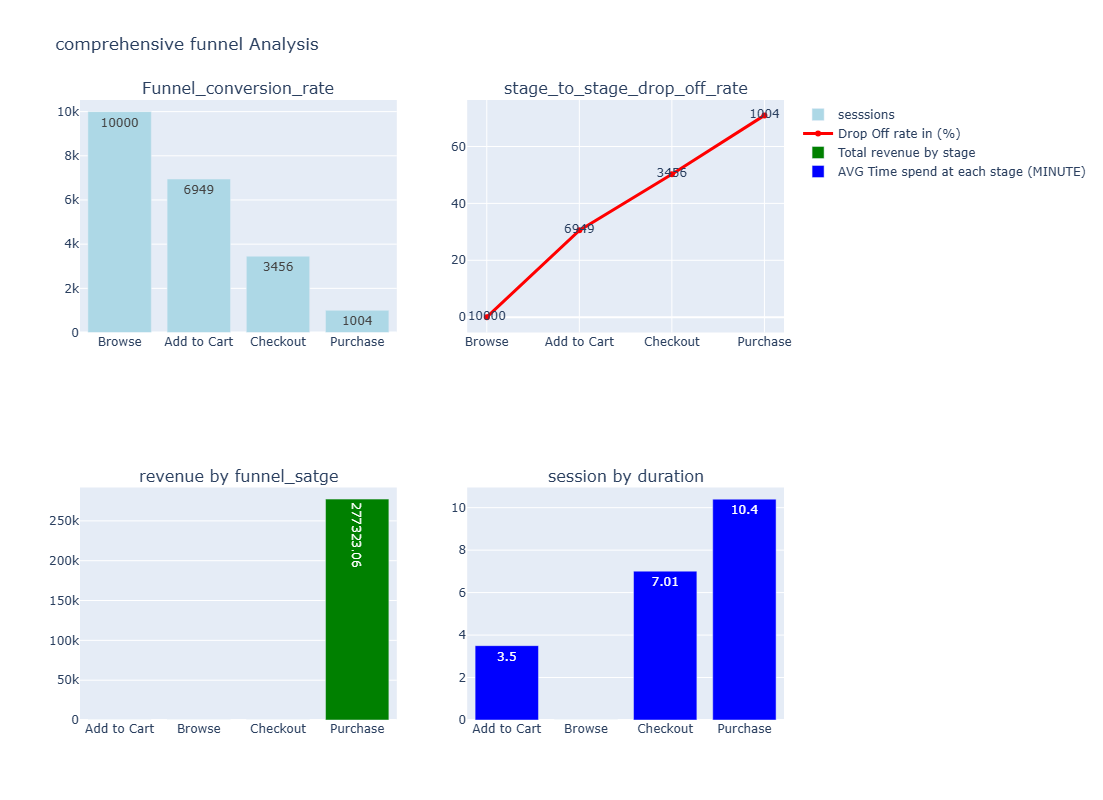

In [69]:
fig=make_subplots(
    
rows=2,cols=2,
specs=[[{'secondary_y': False},
{'secondary_y':False}],[{'secondary_y': False},{'secondary_y': False}]],
subplot_titles=('Funnel_conversion_rate','stage_to_stage_drop_off_rate',
'revenue by funnel_satge','session by duration')
)


fig.add_trace(
    go.Bar(x=funnel_df['stage'],y=funnel_df['sessions'],
    text=funnel_df['sessions'],textposition='auto',
    marker_color='lightblue', name='sesssions'
    ),
    row=1,col=1)

fig.add_trace(
    go.Scatter(x=funnel_df['stage'],y=funnel_df['drop_off_rate'],
           text=funnel_df['sessions'],mode='lines+markers+text',
           name='Drop Off rate in (%)',line=dict(color='red',width=3)),
    row=1,col=2)

revenue_by_stage=session_summary.groupby('max_funnel_stage')['Revenue'].sum().reset_index()

fig.add_trace(
    go.Bar(x=revenue_by_stage['max_funnel_stage'],y=revenue_by_stage['Revenue'],
           name='Total revenue by stage',
           text=[f"{x}" for x in revenue_by_stage['Revenue']],
           textposition='auto',marker_color='green'),row=2,col=1)

session_duration=session_summary.groupby('max_funnel_stage')['session_duration_time'].mean().reset_index()

fig.add_trace(
    go.Bar(x=session_duration['max_funnel_stage'],y=session_duration['session_duration_time'],
           name='AVG Time spend at each stage (MINUTE)',marker_color='blue',
           text=session_duration['session_duration_time'].round(2),textposition='auto'),
    
    row=2,col=2)

fig.update_layout(height=800,title_text='comprehensive funnel Analysis')
fig.show()

## Channel Performance Analysis

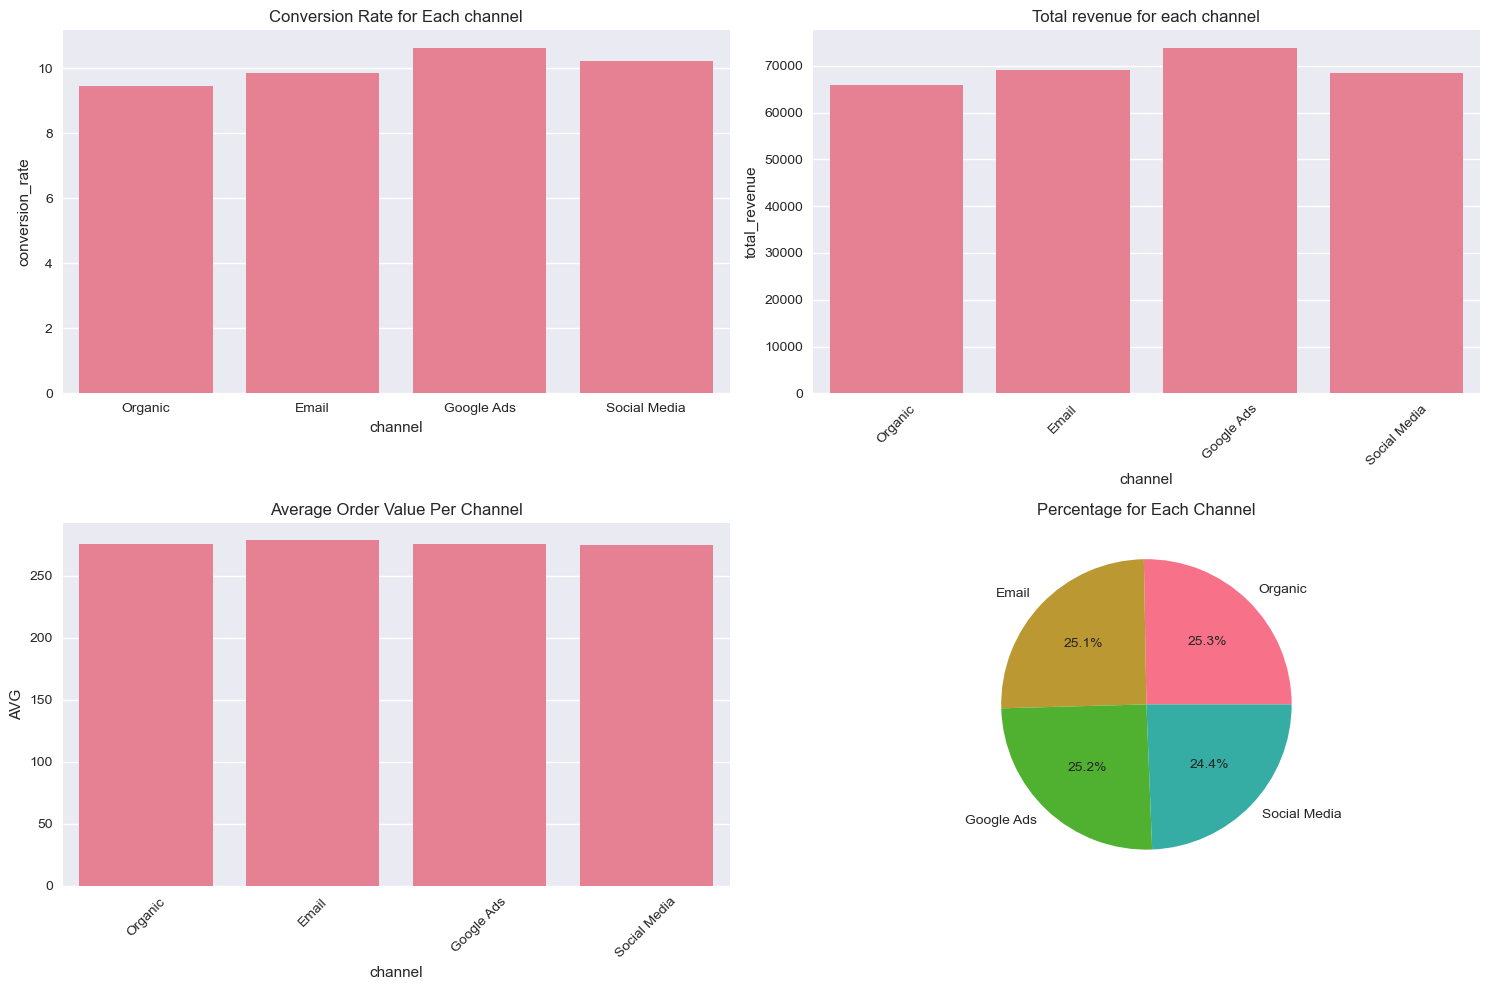

In [89]:
channel_performance=[]
for channel in df['Channel'].unique():
    channel_session=session_summary[session_summary['Channel']==channel]
    total_session=len(channel_session)
    if total_session>0:
        channel_matrics={'channel':channel,
                         'total_session':total_session}
        for i,stage in enumerate(funnel_stages):
            if i==0:
                count=total_session
            else:
                count=len(channel_session[channel_session['max_funnel_stage'].isin(funnel_stages[i:])])

        channel_matrics[f'{stage}_sessiom']=count
        channel_matrics[f'{stage}_rate']=(count/total_session)*100


        purchase_session=channel_session[channel_session['max_funnel_stage']=='Purchase']
        channel_matrics['total_revenue']=purchase_session['Revenue'].sum()
        channel_matrics['AVG']=purchase_session['Revenue'].mean() if len(purchase_session)>0 else 0
        channel_matrics['conversion_rate']=len(purchase_session)/total_session*100

        channel_performance.append(channel_matrics)

channel_df=pd.DataFrame(channel_performance)
channel_df
    



fig, ((ax1,ax2),(ax3,ax4))=plt.subplots(2,2,figsize=(15,10))
sns.barplot(data=channel_df,x='channel',y='conversion_rate',ax=ax1)
ax1.set_title('Conversion Rate for Each channel')
ax2.tick_params(axis='x',rotation=45)

sns.barplot(data=channel_df,x='channel',y='total_revenue',ax=ax2)
ax2.set_title("Total revenue for each channel")
ax2.tick_params(axis='x',rotation=45)


sns.barplot(data=channel_df,x='channel',y='AVG',ax=ax3)
ax3.set_title("Average Order Value Per Channel")
ax3.tick_params(axis='x',rotation=45)


channel_df['session_percent']=channel_df['total_session']/channel_df['total_session'].sum()*100
ax4.pie(channel_df['session_percent'],labels=channel_df['channel'],autopct='%1.1f%%')
ax4.set_title("Percentage for Each Channel")


plt.tight_layout()
plt.show()
              
    
    

## Regional Analysis


Regional Performance


,Total_Sessions,Total_Revenue,session_duration_time,Converted_Sessions,Conversion_Rate,AOV
Region,,,,,,
East,2548,66116.01,3.881083,245,9.62,269.86
North,2463,68645.13,3.988632,253,10.27,271.32
South,2543,77421.45,3.992922,268,10.54,288.89
West,2446,65140.47,4.087490,238,9.73,273.70


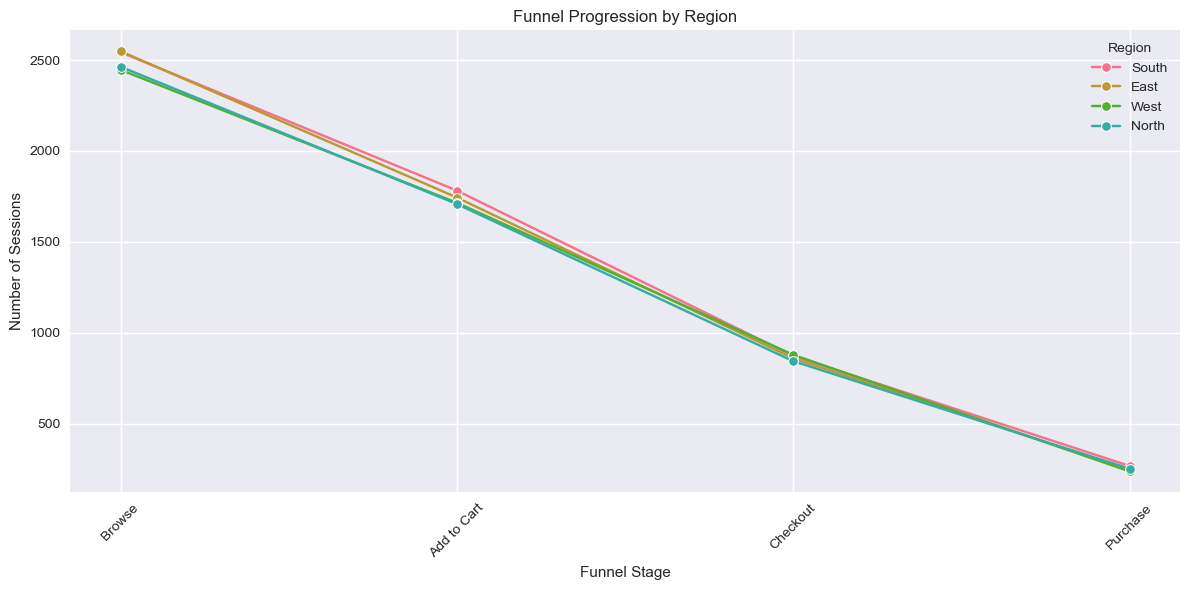

In [93]:


# Calculate regional summary statistics
regional_analysis = (
    session_summary
    .groupby("Region")
    .agg({
        "Session_id": "count",
        "Revenue": "sum",
        "session_duration_time": "mean"
    })
    .rename(columns={
        "Session_id": "Total_Sessions",
        "Revenue": "Total_Revenue"
    })
)

regional_conversion = (
    session_summary[
        session_summary["max_funnel_stage"] == "Purchase"
    ]
    .groupby("Region")
    .size()
)

regional_analysis["Converted_Sessions"] = regional_conversion


regional_analysis["Converted_Sessions"] = (
    regional_analysis["Converted_Sessions"]
    .fillna(0)
    .astype(int)
)


regional_analysis["Conversion_Rate"] = (
    regional_analysis["Converted_Sessions"]
    / regional_analysis["Total_Sessions"]
    * 100
).round(2)


regional_analysis["AOV"] = (
    regional_analysis["Total_Revenue"]
    / regional_analysis["Converted_Sessions"].replace(0, np.nan)
).round(2)

print("Regional Performance")
display(regional_analysis)



regional_funnel_data = []


for region in df["Region"].unique():

    region_sessions = session_summary[
        session_summary["Region"] == region
    ]

    
    for stage in funnel_stages:


        if stage == "Browse":
            count = len(region_sessions)

        else:
            
            count = len(
                region_sessions[
                    region_sessions["max_funnel_stage"].isin(
                        funnel_stages[
                            funnel_stages.index(stage):
                        ]
                    )
                ]
            )

        
        regional_funnel_data.append({
            "Region": region,
            "Stage": stage,
            "Sessions": count
        })


regional_funnel_df = pd.DataFrame(regional_funnel_data)



plt.figure(figsize=(12, 6))

sns.lineplot(
    data=regional_funnel_df,
    x="Stage",
    y="Sessions",
    hue="Region",
    marker="o"
)

plt.title("Funnel Progression by Region")
plt.xlabel("Funnel Stage")
plt.ylabel("Number of Sessions")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

Device Performance


,Total_Sessions,Revenue,session_duration_time,Purchases,Conversion_Rate,AOV
Device,,,,,,
Desktop,3366,98471.83,4.013072,356,10.58,276.61
Mobile,3263,84231.10,3.959853,309,9.47,272.59
Tablet,3371,94620.13,3.985761,339,10.06,279.12


 Product Category Performance


,Total_Sessions,Revenue,Purchases,Conversion_Rate,AOV,Revenue_Per_Session
Product Category,,,,,,
Beauty,2021,50353.36,191,9.45,263.63,24.92
Electronics,2052,62938.46,229,11.16,274.84,30.67
Fashion,2001,58075.22,211,10.54,275.24,29.02
Home,1978,50100.01,184,9.30,272.28,25.33
Sports,1948,55856.01,189,9.70,295.53,28.67


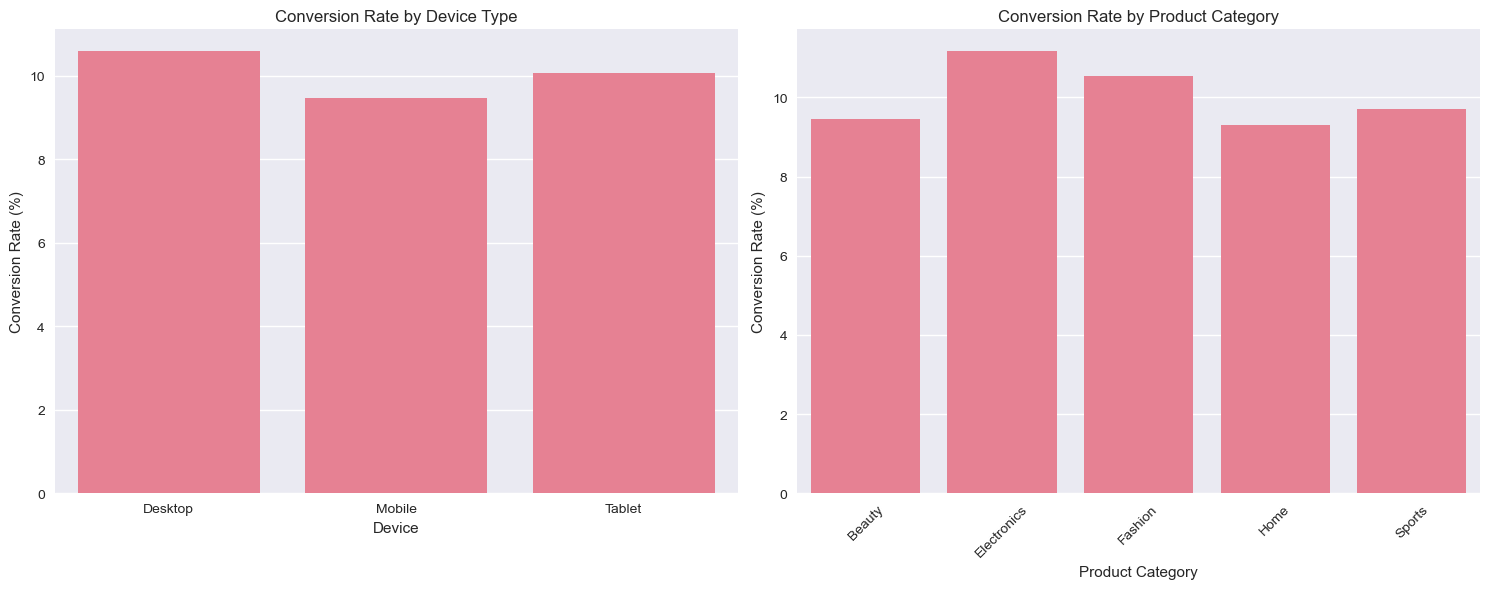

In [95]:

# Device Performance Analysis


device_analysis = (
    session_summary
    .groupby("Device")
    .agg({
        "Session_id": "count",
        "Revenue": "sum",
        "session_duration_time": "mean",
        "max_funnel_stage": lambda x: (x == "Purchase").sum()
    })
    .rename(columns={
        "Session_id": "Total_Sessions",
        "max_funnel_stage": "Purchases"
    })
)


device_analysis["Conversion_Rate"] = (
    device_analysis["Purchases"]
    / device_analysis["Total_Sessions"]
    * 100
).round(2)


device_analysis["AOV"] = (
    device_analysis["Revenue"]
    / device_analysis["Purchases"].replace(0, np.nan)
).round(2)

print("Device Performance")
display(device_analysis)

# Product Category Performance Analysis


product_analysis = (
    session_summary
    .groupby("Product Category")
    .agg({
        "Session_id": "count",
        "Revenue": "sum",
        "max_funnel_stage": lambda x: (x == "Purchase").sum()
    })
    .rename(columns={
        "Session_id": "Total_Sessions",
        "max_funnel_stage": "Purchases"
    })
)


product_analysis["Conversion_Rate"] = (
    product_analysis["Purchases"]
    / product_analysis["Total_Sessions"]
    * 100
).round(2)

#
product_analysis["AOV"] = (
    product_analysis["Revenue"]
    / product_analysis["Purchases"].replace(0, np.nan)
).round(2)


product_analysis["Revenue_Per_Session"] = (
    product_analysis["Revenue"]
    / product_analysis["Total_Sessions"]
).round(2)

print(" Product Category Performance")
display(product_analysis)




fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))


sns.barplot(
    data=device_analysis.reset_index(),
    x="Device",
    y="Conversion_Rate",
    ax=ax1
)

ax1.set_title("Conversion Rate by Device Type")
ax1.set_xlabel("Device")
ax1.set_ylabel("Conversion Rate (%)")




sns.barplot(
    data=product_analysis.reset_index(),
    x="Product Category",
    y="Conversion_Rate",
    ax=ax2
)

ax2.set_title("Conversion Rate by Product Category")
ax2.set_xlabel("Product Category")
ax2.set_ylabel("Conversion Rate (%)")
ax2.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

## Time Based Analysis

Daily Performance Trends


,Daily_Sessions,Daily_Users,Revenue,Daily_Conversions,Daily_Conversion_Rate
date,,,,,
2025-12-30,317,317,9673.30,32,10.09
2025-12-31,338,338,9115.30,34,10.06
2026-01-01,345,345,5634.03,27,7.83
2026-01-02,322,322,9875.70,34,10.56
2026-01-03,344,344,12434.29,42,12.21
2026-01-04,320,320,6887.50,27,8.44
2026-01-05,331,331,9225.22,32,9.67
2026-01-06,367,367,10998.27,39,10.63
2026-01-07,341,341,12464.35,44,12.90


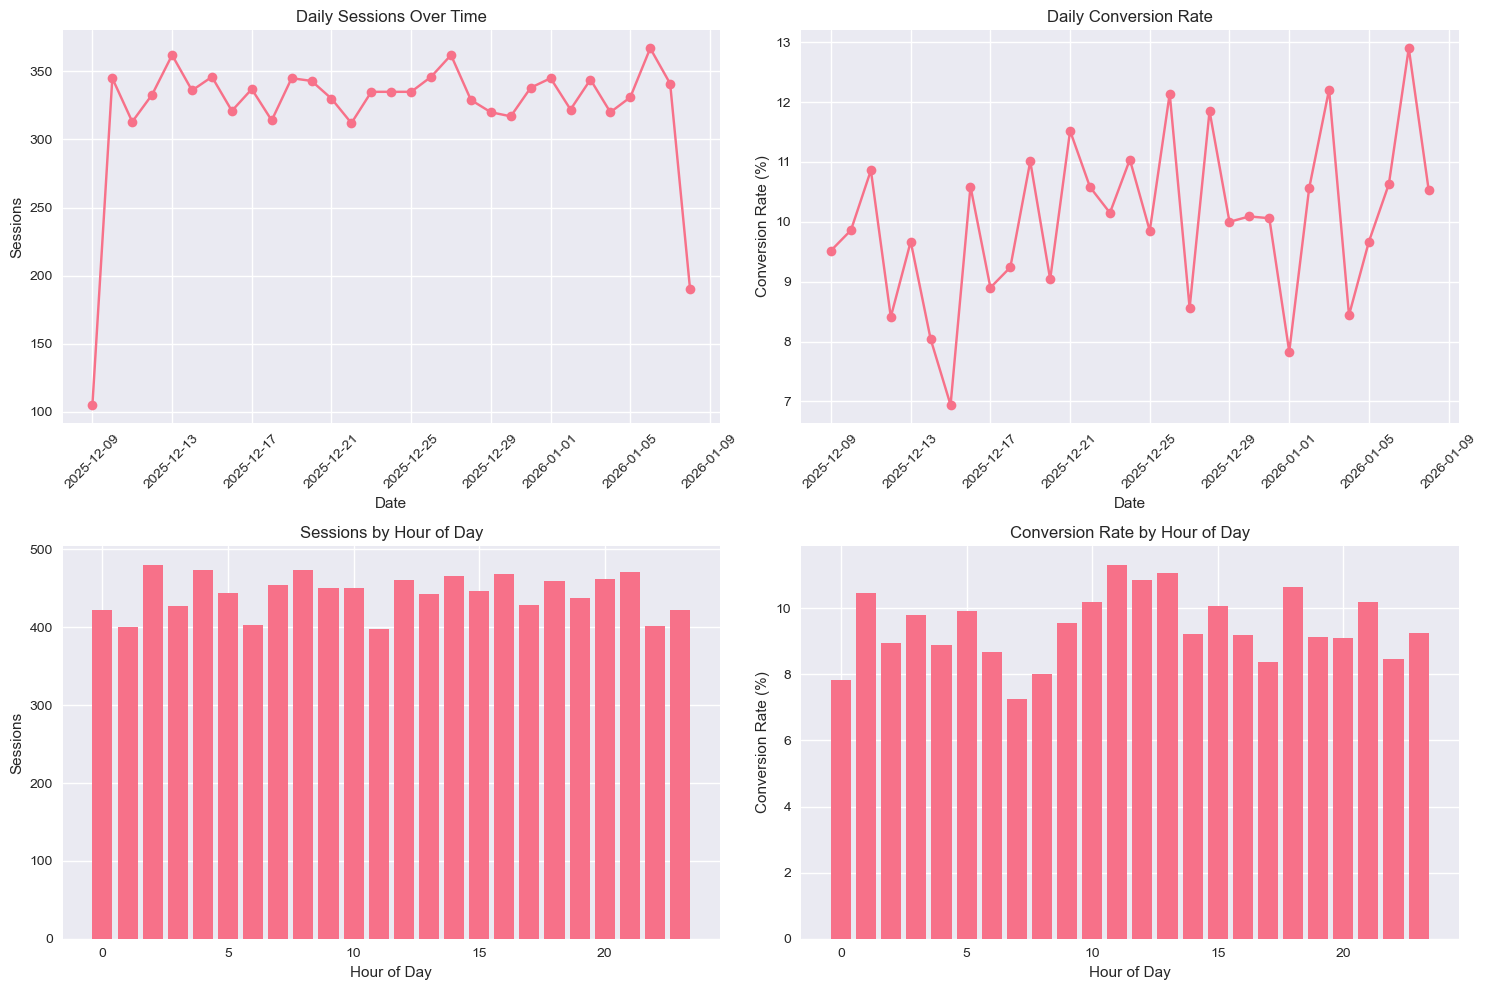

,stage,sessions,session_order,conversion_rate,drop_off_rate
0,Browse,10000,0,100.00,0.00
1,Add to Cart,6949,1,69.49,30.51
2,Checkout,3456,2,34.56,50.27
3,Purchase,1004,3,10.04,70.95


In [104]:


daily_metrics = (
    df.groupby("date")
    .agg({
        "Session ID": "nunique",
        "User ID": "nunique",
        "Revenue": "sum"
    })
    .rename(columns={
        "Session ID": "Daily_Sessions",
        "User ID": "Daily_Users"
    })
)


daily_conversions = (
    session_summary[
        session_summary["max_funnel_stage"] == "Purchase"
    ]
    .groupby(
        session_summary["Session_start"].dt.date
    )
    .size()
)

daily_metrics["Daily_Conversions"] = daily_conversions

# Replace missing values with 0
daily_metrics["Daily_Conversions"] = (
    daily_metrics["Daily_Conversions"]
    .fillna(0)
    .astype(int)
)

# Daily Conversion Rate
daily_metrics["Daily_Conversion_Rate"] = (
    daily_metrics["Daily_Conversions"]
    / daily_metrics["Daily_Sessions"]
    * 100
).round(2)

print("Daily Performance Trends")
display(daily_metrics.tail(10))


hourly_sessions = (
    df.groupby("hour")
    .agg({
        "Session ID": "nunique",
        "Revenue": "sum"
    })
    .rename(columns={
        "Session ID": "Hourly_Sessions"
    })
)



hourly_conversions = session_summary[
    session_summary["max_funnel_stage"] == "Purchase"
].copy()

hourly_conversions["Hour"] = (
    hourly_conversions["Session_start"].dt.hour
)

hourly_conversion_counts = (
    hourly_conversions
    .groupby("Hour")
    .size()
)

hourly_sessions["Hourly_Conversions"] = hourly_conversion_counts


hourly_sessions["Hourly_Conversions"] = (
    hourly_sessions["Hourly_Conversions"]
    .fillna(0)
    .astype(int)
)


hourly_sessions["Hourly_Conversion_Rate"] = (
    hourly_sessions["Hourly_Conversions"]
    / hourly_sessions["Hourly_Sessions"]
    * 100
).round(2)




fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(
    2,
    2,
    figsize=(15, 10)
)



ax1.plot(
    daily_metrics.index,
    daily_metrics["Daily_Sessions"],
    marker="o"
)

ax1.set_title("Daily Sessions Over Time")
ax1.set_xlabel("Date")
ax1.set_ylabel("Sessions")
ax1.tick_params(axis="x", rotation=45)



ax2.plot(
    daily_metrics.index,
    daily_metrics["Daily_Conversion_Rate"],
    marker="o"
)

ax2.set_title("Daily Conversion Rate")
ax2.set_xlabel("Date")
ax2.set_ylabel("Conversion Rate (%)")
ax2.tick_params(axis="x", rotation=45)




ax3.bar(
    hourly_sessions.index,
    hourly_sessions["Hourly_Sessions"]
)

ax3.set_title("Sessions by Hour of Day")
ax3.set_xlabel("Hour of Day")
ax3.set_ylabel("Sessions")



ax4.bar(
    hourly_sessions.index,
    hourly_sessions["Hourly_Conversion_Rate"]
)

ax4.set_title("Conversion Rate by Hour of Day")
ax4.set_xlabel("Hour of Day")
ax4.set_ylabel("Conversion Rate (%)")

plt.tight_layout()
plt.show()
funnel_df

## Summary and KPI(key indicator point)

In [109]:


print(" KEY PERFORMANCE INDICATORS (KPIs)")
print("=" * 50)



total_sessions = len(session_summary)

total_revenue = session_summary["Revenue"].sum()

total_orders = len(
    session_summary[
        session_summary["max_funnel_stage"] == "Purchase"
    ]
)

overall_conversion_rate = (
    total_orders
    / total_sessions
    * 100
)

average_order_value = (
    total_revenue
    / total_orders
    if total_orders > 0
    else 0
)

print(f" Overall Conversion Rate : {overall_conversion_rate:.2f}%")
print(f" Total Revenue          : {total_revenue:,.2f}")
print(f" Average Order Value    : {average_order_value:.2f}")
print(f" Total Sessions         : {total_sessions:,}")
print(f" Total Orders           : {total_orders:,}")




browse_to_cart = (
    funnel_df.iloc[1]["sessions"]
    / funnel_df.iloc[0]["sessions"]
    * 100
)

cart_to_checkout = (
    funnel_df.iloc[2]["sessions"]
    / funnel_df.iloc[1]["sessions"]
    * 100
)

checkout_to_purchase = (
    funnel_df.iloc[3]["sessions"]
    / funnel_df.iloc[2]["sessions"]
    * 100
)

print("\n Stage-to-Stage Conversion Rates")
print(f"Browse to  Add to Cart   : {browse_to_cart:.2f}%")
print(f"Add to Cart to Checkout : {cart_to_checkout:.2f}%")
print(f"Checkout to Purchase    : {checkout_to_purchase:.2f}%")




revenue_per_browse = (
    total_revenue
    / funnel_df.iloc[0]["sessions"]
)

revenue_per_cart = (
    total_revenue
    / funnel_df.iloc[1]["sessions"]
)

revenue_per_checkout = (
    total_revenue
    / funnel_df.iloc[2]["sessions"]
)

print("\n Revenue Per Session by Stage")
print(f"Browse Stage   : {revenue_per_browse:.2f}")
print(f"Cart Stage     : {revenue_per_cart:.2f}")
print(f"Checkout Stage : {revenue_per_checkout:.2f}")




bounce_sessions = session_summary[
    session_summary["Bonus Flag"] == "Yes"
]

bounce_rate = (
    len(bounce_sessions)
    / total_sessions
    * 100
)

print(f"\n Bounce Rate : {bounce_rate:.2f}%")



avg_session_duration = (
    session_summary["session_duration_time"]
    .mean()
)

print(
    f" Average Session Duration : "
    f"{avg_session_duration:.2f} minutes"
)

 KEY PERFORMANCE INDICATORS (KPIs)
 Overall Conversion Rate : 10.04%
 Total Revenue          : 277,323.06
 Average Order Value    : 276.22
 Total Sessions         : 10,000
 Total Orders           : 1,004

 Stage-to-Stage Conversion Rates
Browse to  Add to Cart   : 69.49%
Add to Cart to Checkout : 49.73%
Checkout to Purchase    : 29.05%

 Revenue Per Session by Stage
Browse Stage   : 27.73
Cart Stage     : 39.91
Checkout Stage : 80.24

 Bounce Rate : 100.00%
 Average Session Duration : 3.99 minutes


 Analysis Complete!
 Report exported successfully as 'funnel_analysis_report.xlsx'


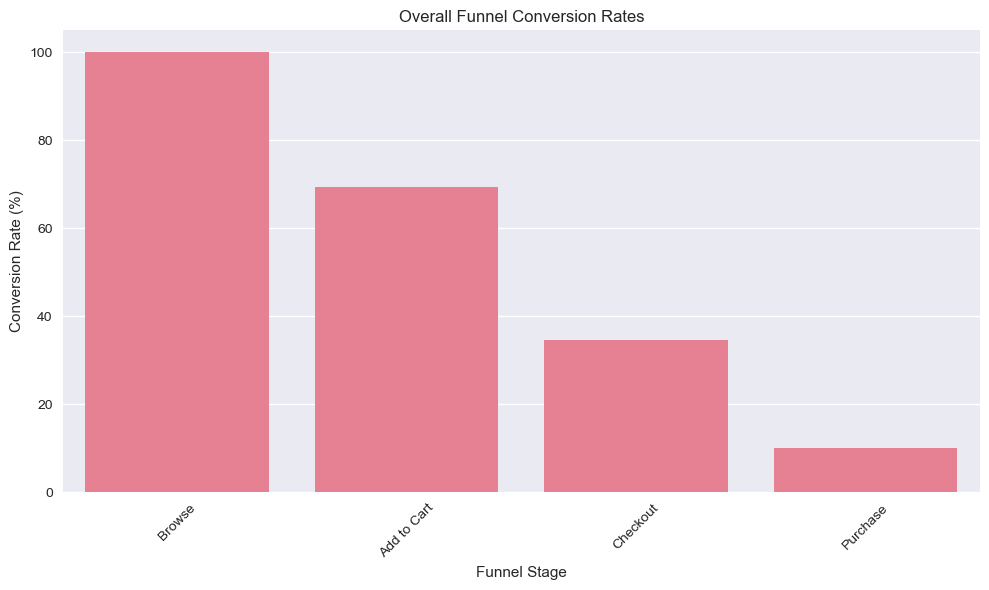

 Key visualization saved as 'funnel_conversion_rates.png'


In [110]:


report_data = {
    "Overall_Funnel": funnel_df,
    "Channel_Performance": channel_df,
    "Regional_Analysis": regional_analysis,
    "Device_Performance": device_analysis,
    "Product_Performance": product_analysis,
    "Daily_Trends": daily_metrics,
    "Hourly_Patterns": hourly_sessions
}



with pd.ExcelWriter("funnel_analysis_report.xlsx") as writer:

    for sheet_name, data in report_data.items():

        
        data.reset_index().to_excel(
            writer,
            sheet_name=sheet_name,
            index=False
        )

print(" Analysis Complete!")
print(" Report exported successfully as 'funnel_analysis_report.xlsx'")




plt.figure(figsize=(10, 6))

sns.barplot(
    data=funnel_df,
    x="stage",
    y="conversion_rate"
)

plt.title("Overall Funnel Conversion Rates")
plt.xlabel("Funnel Stage")
plt.ylabel("Conversion Rate (%)")
plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "funnel_conversion_rates.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(" Key visualization saved as 'funnel_conversion_rates.png'")